In [13]:
import os
import sys 

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import pickle
import json 
import pandas as pd
import seaborn as sns

# collect the full path to this script 
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
output_directory = os.path.join(parent_directory, 'notebooks', 'output_csv')

from utils.plot_utils import plot_kde_ridge
from utils.functions import get_2d_jointplot_with_list_of_series
from utils.general import setup_environment, create_folders_if_they_do_not_exist

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

### Supplementary 2 b

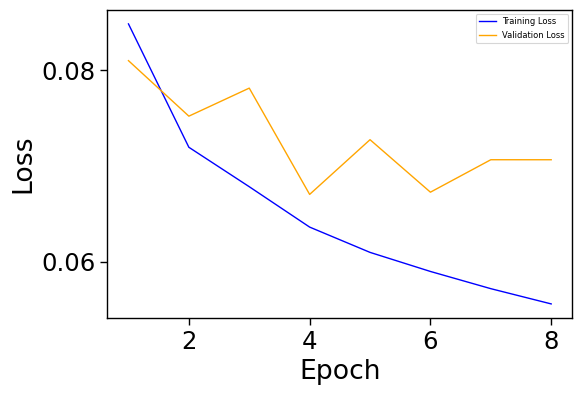

In [14]:
training_data_csv_path = os.path.join(output_directory, 'training_validation_loss_batchloss_20250208_103426.csv')
training_loss_data = pd.read_csv(training_data_csv_path)

fig, ax = plt.subplots(figsize=(6, 4))
epochs = training_loss_data["Epoch"].values
train_loss = training_loss_data["Average Training Loss"].values
val_loss = training_loss_data["Validation Loss"].values
ax.plot(epochs, train_loss, label="Training Loss", color='blue', linewidth=1)
ax.plot(epochs, val_loss, label="Validation Loss", color='orange', linewidth=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yticks([0.06, 0.08])
ax.set_xticks([2, 4, 6, 8])
ax.legend(fontsize=6)


### Supplementary 2 d

In [15]:
csv_path = os.path.join(output_directory, 'calibration_curve_data.csv')
df = pd.read_csv(csv_path)

fraction_of_positives = df['fraction_of_positives'].values
mean_predicted_value = df['mean_predicted_value'].values


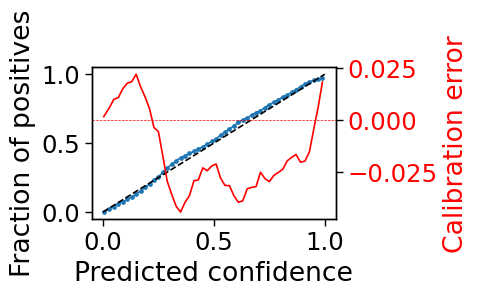

In [16]:
figsize_mm = (80, 50)
figsize = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig, ax = plt.subplots(figsize=figsize)  # DPI is fixed to 600 for publication quality

calibration_error = mean_predicted_value - fraction_of_positives
ax.plot(mean_predicted_value, fraction_of_positives, marker=".", label="Calibration curve")
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Ideal calibration")
ax.set_xlabel("Predicted confidence")
ax.set_ylabel("Fraction of positives")
# add secondary y-axis for calibration error
ax2 = ax.twinx()
ax2.set_ylabel("Calibration error", color="red")
# axis labels in red
ax2.tick_params(axis='y', labelcolor='red')
ax2.plot(mean_predicted_value, calibration_error, color="red", label="Calibration error")
ax2.axhline(0, color="red", linestyle="--", linewidth=0.5)


## Supplementary 2 e

In [17]:
figsize_mm = (50, 80)
figsize = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)


csv_file_path = os.path.join(output_directory, 'f1_scores_kde_values_means.csv')
df = pd.read_csv(csv_file_path)

emdb_ids = df['emdb_id'].unique()
f1_scores_dictionary = {int(x): float(df[df['emdb_id']==x]['f1_score'].values[0]) for x in emdb_ids}
kde_values_dictionary = {int(x): df[df['emdb_id']==x]['kde_value'].values for x in emdb_ids}
means_emdb = {int(x): float(df[df['emdb_id']==x]['mean_value'].values[0]) for x in emdb_ids}

EMDB: 7133 & F1 score: 0.2685231599701986 & Mean KDE value: 0.29
EMDB: 4288 & F1 score: 0.4066887167061294 & Mean KDE value: 0.20
EMDB: 8958 & F1 score: 0.4623017580085463 & Mean KDE value: 0.54
EMDB: 8960 & F1 score: 0.54046103560984 & Mean KDE value: 0.55
EMDB: 4032 & F1 score: 0.6501596143066799 & Mean KDE value: 0.36
EMDB: 7882 & F1 score: 0.6744508074348307 & Mean KDE value: 0.39
EMDB: 4646 & F1 score: 0.738881244461029 & Mean KDE value: 0.46
EMDB: 4272 & F1 score: 0.7444379797552381 & Mean KDE value: 0.56
EMDB: 4588 & F1 score: 0.7815807611052391 & Mean KDE value: 0.45
EMDB: 4589 & F1 score: 0.7862877779008457 & Mean KDE value: 0.43
EMDB: 8702 & F1 score: 0.793616161299057 & Mean KDE value: 0.45
EMDB: 9934 & F1 score: 0.8345284773982361 & Mean KDE value: 0.48
EMDB: 7009 & F1 score: 0.8562601507326776 & Mean KDE value: 0.46
EMDB: 257 & F1 score: 0.8788453884378271 & Mean KDE value: 0.45
EMDB: 4746 & F1 score: 0.8910499344227522 & Mean KDE value: 0.51
EMDB: 9939 & F1 score: 0.90769

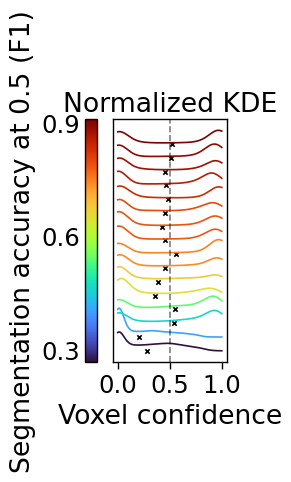

In [18]:
fig, ax = plt.subplots(figsize=figsize)
ax = plot_kde_ridge(f1_scores_dictionary, kde_values_dictionary, means=means_emdb, ax=ax, \
                        clabel="Segmentation accuracy at 0.5 (F1)", xlabel="Voxel confidence", ylabel="Normalized KDE")
ax.axvline(x=0.5, linestyle="--", color="black", alpha=0.5)

## Supplementary 2 f

In [19]:
ff_csv =  os.path.join(output_directory, "flatness_fragmentation_ratios.csv")
df = pd.read_csv(ff_csv)
all_flatness_ratios = df["flatness_ratio"].values.tolist()
all_fragmentation_ratios = df["fragmentation_ratio"].values.tolist()

all_emdb_ids = df["emdb_id"].astype(str).values.tolist()
all_emdb_ids = [x.zfill(4) for x in all_emdb_ids]

predicted_flatness_fragmentation_ratios_path = os.path.join(output_directory, 'test_flatness_fragmentation_f1.json')
with open(predicted_flatness_fragmentation_ratios_path, 'r') as f:
    predicted_flatness_fragmentation_ratios = json.load(f)

In [20]:
# list_of_flatness_ratios = []
# list_of_fragmentation_ratios = []
# list_of_f1_scores = []

# emdb_list_for_plot = list(predicted_flatness_fragmentation_ratios.keys())
# for chosen_emdb_id in emdb_list_for_plot:
#     flatness_ratio_series = []
#     fragmentation_ratio_series = []
#     f1_score_series = []
#     for threshold in predicted_flatness_fragmentation_ratios[str(chosen_emdb_id)]:
#         flatness_ratio_series.append(predicted_flatness_fragmentation_ratios[chosen_emdb_id][threshold]["flatness"])
#         fragmentation_ratio_series.append(predicted_flatness_fragmentation_ratios[chosen_emdb_id][threshold]["fragmentation"])
#         f1_score_series.append(predicted_flatness_fragmentation_ratios[chosen_emdb_id][threshold]["f1_score"])

#     list_of_flatness_ratios.append(flatness_ratio_series)
#     list_of_fragmentation_ratios.append(fragmentation_ratio_series)
#     list_of_f1_scores.append(f1_score_series)



In [21]:
# figsize_mm = (30, 50)
# get_2d_jointplot_with_list_of_series(
#     all_flatness_ratios, all_fragmentation_ratios, list_of_flatness_ratios, list_of_fragmentation_ratios, list_of_f1_scores, \
#     emdb_id_list = list(predicted_flatness_fragmentation_ratios.keys()), x_label="Flatness ratio", y_label="Fragmentation ratio",
#     save_path=None, figsize_mm=figsize_mm, \
#     probability_levels_required = [0, 0.5, 0.68, 0.8, 0.9], 
#     fontsize=10, 
#     xticks=[0.2, 0.4, 0.6, 0.8], yticks=[0.2, 0.4, 0.6, 0.8], \
#     cmin=0.6, cmax=1, get_trajectory=False\
#     )

In [22]:
list_of_flatness_ratios = []
list_of_fragmentation_ratios = []
list_of_f1_scores = []

emdb_list_for_plot = ["257"]
for chosen_emdb_id in emdb_list_for_plot:
    flatness_ratio_series = []
    fragmentation_ratio_series = []
    f1_score_series = []
    for threshold in predicted_flatness_fragmentation_ratios[str(chosen_emdb_id)]:
        flatness_ratio_series.append(predicted_flatness_fragmentation_ratios[chosen_emdb_id][threshold]["flatness"])
        fragmentation_ratio_series.append(predicted_flatness_fragmentation_ratios[chosen_emdb_id][threshold]["fragmentation"])
        f1_score_series.append(predicted_flatness_fragmentation_ratios[chosen_emdb_id][threshold]["f1_score"])

    list_of_flatness_ratios.append(flatness_ratio_series)
    list_of_fragmentation_ratios.append(fragmentation_ratio_series)
    list_of_f1_scores.append(f1_score_series)



0 [0.64705882 0.         0.14901961 1.        ] 0.7232620136827279 end


/home/abharadwaj1/thesis/publications/utils/functions.py:272: UserWarning: linewidths is ignored by contourf
  cf = g.ax_joint.contourf(xi, yi, zi, levels=levels_increasing, cmap='viridis', linewidths=1, alpha=0.5)


<Figure size 708.661x1181.1 with 0 Axes>

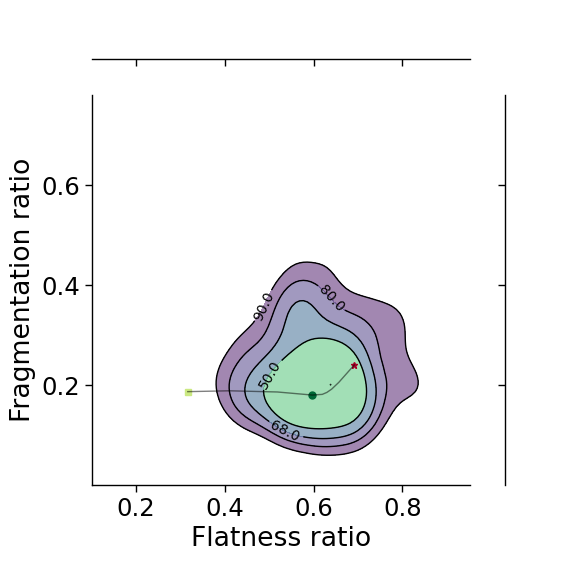

In [23]:
figsize_mm = (30, 50)
get_2d_jointplot_with_list_of_series(
    all_flatness_ratios, all_fragmentation_ratios, list_of_flatness_ratios, list_of_fragmentation_ratios, list_of_f1_scores, \
    emdb_id_list = list(predicted_flatness_fragmentation_ratios.keys()), x_label="Flatness ratio", y_label="Fragmentation ratio",
    save_path=None, figsize_mm=figsize_mm, \
    probability_levels_required = [0, 0.5, 0.68, 0.8, 0.9], 
    fontsize=10, 
    xticks=[0.2, 0.4, 0.6, 0.8], yticks=[0.2, 0.4, 0.6, 0.8], \
    cmin=0.6, cmax=1, get_trajectory=True\
    )